<a href="https://colab.research.google.com/github/korkutanapa/OEE_ARTICLE_STUDIES/blob/main/FULL_CODE_TDA_TIME_SERIES_PREDICTION_gm2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A Novel Algorithmic Framework for Time-Series Prediction via Topological Data Analysis

This framework is a prediction tool for univariate time series.

In [ ]:
%pip install -q "numpy==1.26.4" "scipy==1.11.4" "scikit-learn==1.3.2"
%pip install -q "giotto-tda==0.6.2"

In [ ]:
# Install feature_engine (run this once in a cell)
%pip install feature_engine

In [ ]:
!pip install pmdarima

In [ ]:
%pip install pyswarm

In [1]:
import pandas as pd
# Load the file for time series
data_path = '/content/TRIAL_SET_10_GM2ts.xlsx'
data = pd.read_excel(data_path)

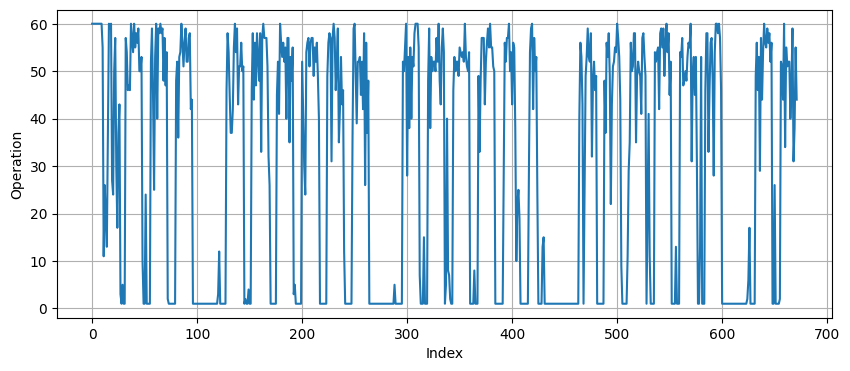

In [2]:
import matplotlib.pyplot as plt
# Reset index
data = data.reset_index(drop=True)
# Plot the 'Operation' column by index
plt.figure(figsize=(10, 4))
plt.plot(data['Operation'].values)
plt.xlabel('Index')
plt.ylabel('Operation')
plt.grid(True)
# Show the plot
plt.show()

In [3]:
# ============================
# Ask for seasonal period m
# ============================
# Examples:
#   hourly data with shift pattern  -> 8
#   hourly data with daily pattern  -> 24
#   hourly data with weekly pattern -> 168
seasonal_period = int(input("Enter expected seasonal period m (e.g. 8, 12, 24): "))

Enter expected seasonal period m (e.g. 8, 12, 24): 8


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm

# ============================
# 1. Prepare target series
# ============================
y = data['Operation'].astype(float)

# ============================
# 2. Define train / test split
#    (test = last test_len points)
# ============================
test_len = int(input("Enter length of test data (number of last observations): "))

if test_len <= 0 or test_len >= len(y):
    raise ValueError(f"test_len must be between 1 and {len(y) - 1}")

y_train = y[:-test_len]   # used for fitting auto_arima
y_test  = y[-test_len:]   # held out for evaluation

print(f"Train length: {len(y_train)}, Test length: {len(y_test)}")

# ============================
# 3. Fit SARIMA via auto_arima
#    on TRAIN DATA ONLY
# ============================
model = pm.auto_arima(
    y_train,                # <<< IMPORTANT: only train here
    start_p=0, max_p=4,
    start_q=0, max_q=4,
    d=None,
    max_d=2,

    start_P=0, max_P=4,
    start_Q=0, max_Q=4,
    D=None,
    max_D=2,

    seasonal=True,
    m=seasonal_period,

    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=False,
    n_jobs=-1
)

print("\nBest SARIMA model found by auto_arima (fitted on train):")
print(model.summary())

# ============================
# 4. (Optional) Forecast on TEST set
# ============================
# Forecast strictly out-of-sample for test_len steps
y_pred_test = model.predict(n_periods=test_len)

# Now you can compare y_test vs y_pred_test with MAE, MAPE, etc.


Enter length of test data (number of last observations): 4
Train length: 668, Test length: 4

Best model:  ARIMA(1,0,0)(4,0,0)[8] intercept
Total fit time: 25.436 seconds

Best SARIMA model found by auto_arima (fitted on train):
                                     SARIMAX Results                                     
Dep. Variable:                                 y   No. Observations:                  668
Model:             SARIMAX(1, 0, 0)x(4, 0, 0, 8)   Log Likelihood               -2647.366
Date:                           Mon, 24 Nov 2025   AIC                           5308.732
Time:                                   18:12:07   BIC                           5340.262
Sample:                                        0   HQIC                          5320.947
                                           - 668                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>


Evaluation on TEST set:
MAE           : 12.6333
MAPE_percent  : 36.1794


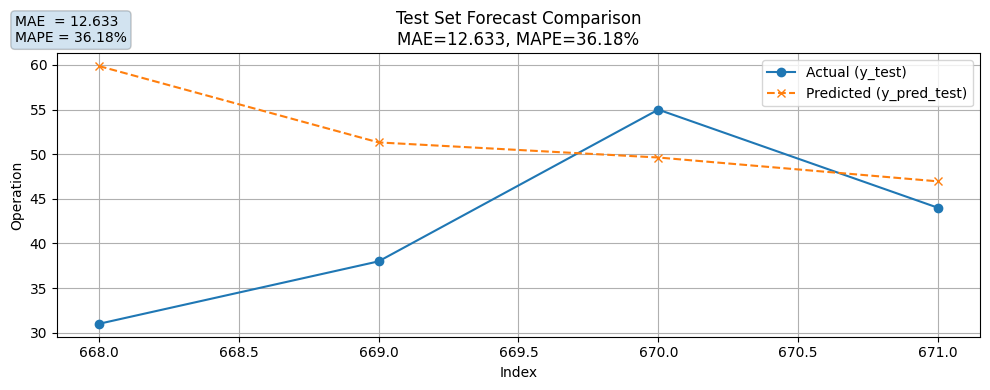

In [5]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Convert predictions to pandas Series with same index as y_test (for plotting & alignment)
y_pred_test = pd.Series(y_pred_test, index=y_test.index)

# ============================
# 5. Evaluation: MAE & MAPE
# ============================
mae = mean_absolute_error(y_test, y_pred_test)
mape = mean_absolute_percentage_error(y_test, y_pred_test) * 100  # percent

print("\nEvaluation on TEST set:")
print(f"MAE           : {mae:.4f}")
print(f"MAPE_percent  : {mape:.4f}")

# ============================
# 6. Plot comparison: y_test vs y_pred_test
# ============================
plt.figure(figsize=(10, 4))
plt.plot(y_test.index, y_test.values, marker='o', linestyle='-', label='Actual (y_test)')
plt.plot(y_pred_test.index, y_pred_test.values, marker='x', linestyle='--', label='Predicted (y_pred_test)')

plt.xlabel('Index')
plt.ylabel('Operation')
plt.title(f'Test Set Forecast Comparison\nMAE={mae:.3f}, MAPE={mape:.2f}%')
plt.grid(True)
plt.legend()

# Optional: text box with metrics
text_str = f"MAE  = {mae:.3f}\nMAPE = {mape:.2f}%"
plt.gcf().text(0.02, 0.95, text_str,
               fontsize=10, va='top', ha='left',
               bbox=dict(boxstyle="round", alpha=0.2))

plt.tight_layout()
plt.show()

In [ ]:
model

DECOMPOSITION PERIOD

Enter number of seasonal periods (1–3): 3
Enter seasonal period #1 (e.g. 8, 24, 168): 8
Enter seasonal period #2 (e.g. 8, 24, 168): 24
Enter seasonal period #3 (e.g. 8, 24, 168): 168
Using seasonal periods: [8, 24, 168]


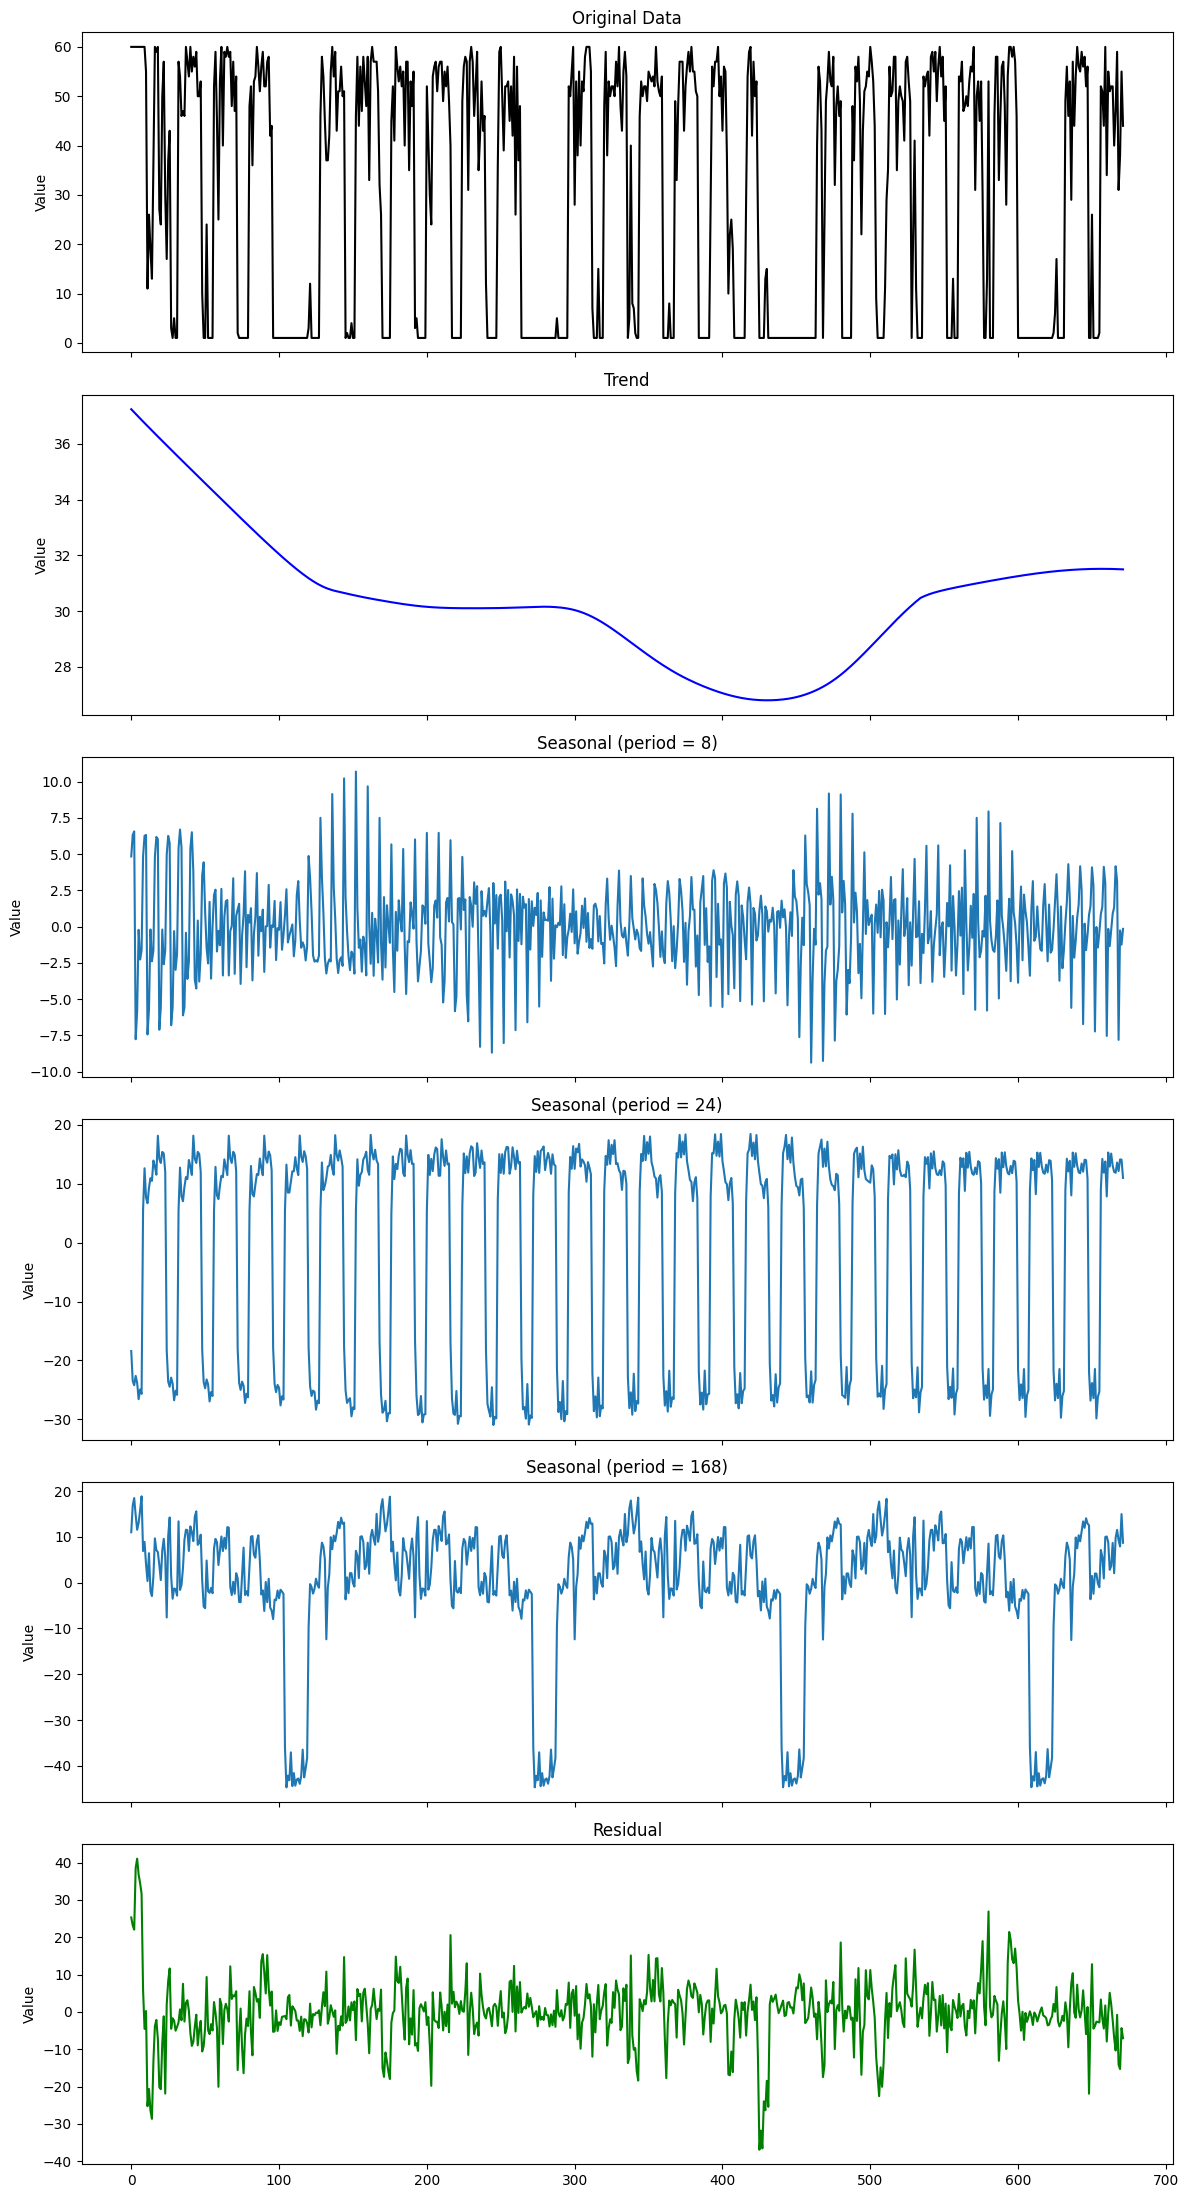


Decomposition done.
decompose_df (train combined series) head:
       total
0  34.684531
1  36.816719
2  37.945246
3  21.407352
4  18.935132

Reference (last test_size original Operation values):
668    31
669    38
670    55
671    44
Name: Operation, dtype: int64


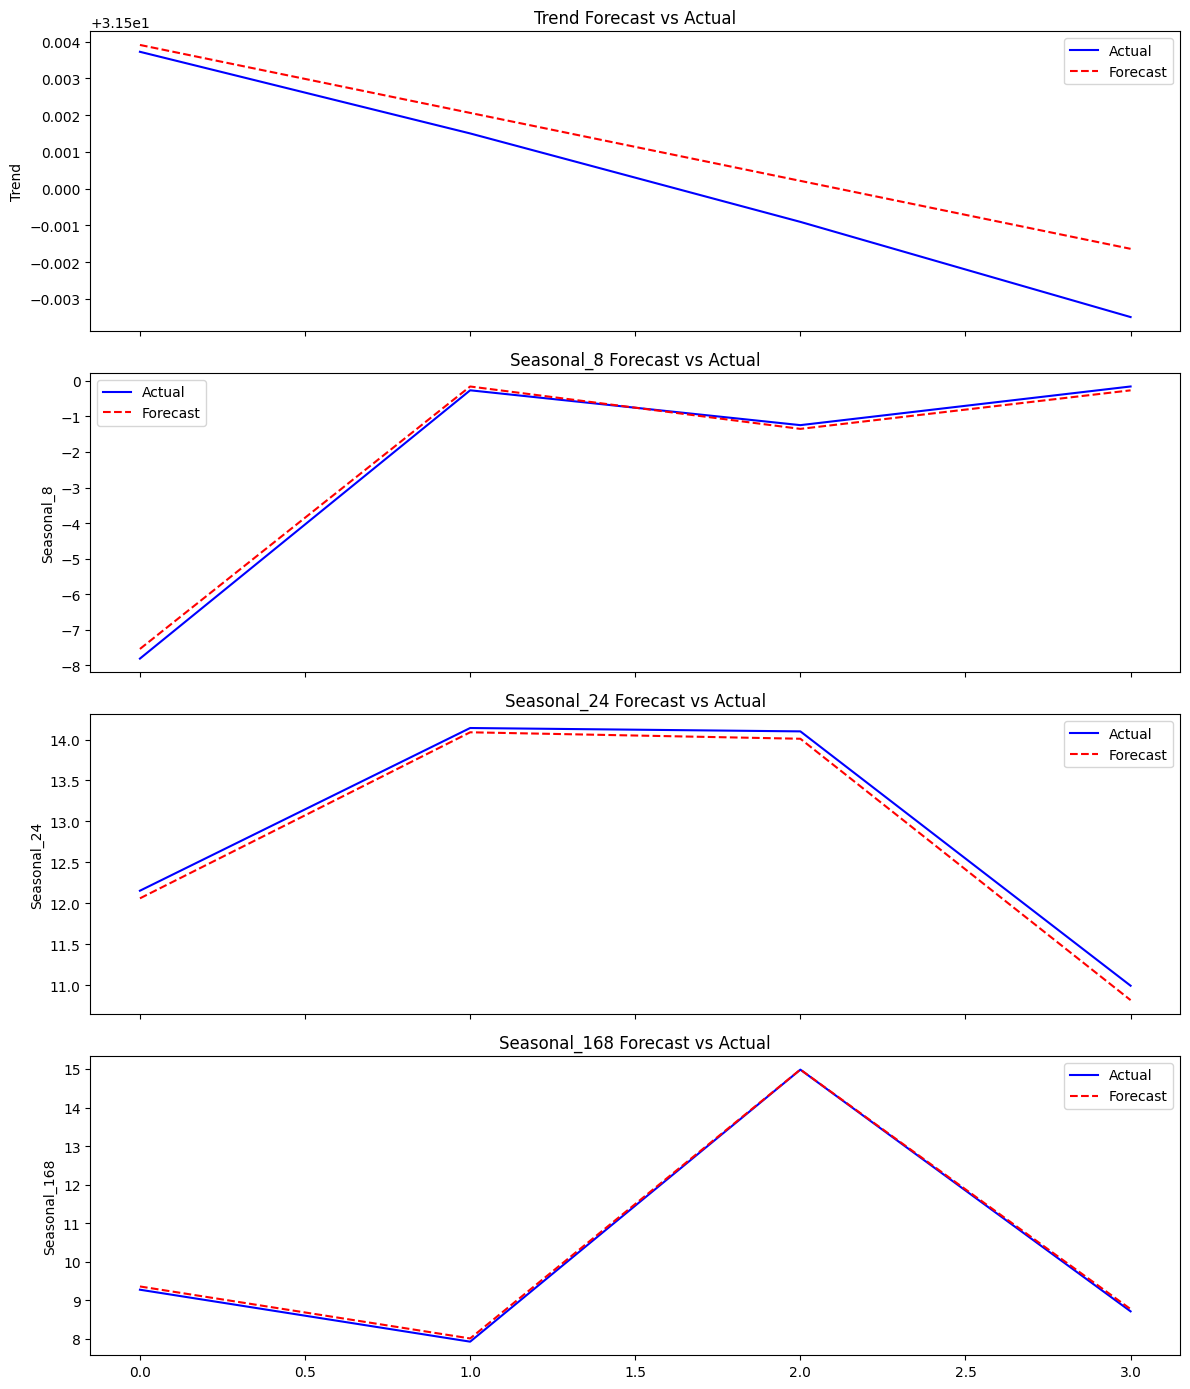


MAE results:
       Trend: 0.0009
  Seasonal_8: 0.1480
 Seasonal_24: 0.1030
Seasonal_168: 0.0571
       Total: 10.1988

MAPE results (%):
       Trend: 0.0030
  Seasonal_8: 30.2730
 Seasonal_24: 0.8447
Seasonal_168: 0.6613
       Total: 27.5211

Summed-up forecast (trend + all seasonalities):
             sum
Index           
668    45.385061
669    53.444542
670    59.144846
671    50.820568
        residual
Index           
0      25.315469
1      23.183281
2      22.054754
3      38.592648
4      41.064868


In [6]:
import pandas as pd
from statsmodels.tsa.seasonal import MSTL
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# -------------------------------------------------
# 1. Ensure data is sorted (uses your existing 'data')
# -------------------------------------------------
data = data.sort_index()

# -------------------------------------------------
# 2. Ask user for seasonalities (1–3)
# -------------------------------------------------
max_seasons = 3
n_seasons = int(input("Enter number of seasonal periods (1–3): "))

if n_seasons < 1 or n_seasons > max_seasons:
    raise ValueError("Number of seasonal periods must be between 1 and 3.")

periods = []
for i in range(n_seasons):
    p = int(input(f"Enter seasonal period #{i+1} (e.g. 8, 24, 168): "))
    periods.append(p)

print("Using seasonal periods:", periods)

# -------------------------------------------------
# 3. MSTL decomposition
# -------------------------------------------------
stl_kwargs = {"seasonal_deg": 0}
mstl_model = MSTL(data['Operation'], periods=tuple(periods), stl_kwargs=stl_kwargs)
res = mstl_model.fit()

trend = res.trend
residual = res.resid

# Collect seasonal components in a dict: {period: series}
seasonal_components = {}
for i, p in enumerate(periods):
    seasonal_components[p] = res.seasonal.iloc[:, i]

# -------------------------------------------------
# 4. Plot original / trend / seasonals / residual
# -------------------------------------------------
n_rows = 3 + n_seasons  # original + trend + each seasonal + residual
fig, axes = plt.subplots(n_rows, 1, figsize=(12, 4 * n_rows), sharex=True)

# Row 0: original
data['Operation'].plot(ax=axes[0], color='black', title='Original Data')
axes[0].set_ylabel('Value')

# Row 1: trend
trend.plot(ax=axes[1], color='blue', title='Trend')
axes[1].set_ylabel('Value')

# Next rows: seasonal components
for i, p in enumerate(periods):
    seasonal_components[p].plot(
        ax=axes[2 + i],
        title=f'Seasonal (period = {p})'
    )
    axes[2 + i].set_ylabel('Value')

# Last row: residual
residual.plot(ax=axes[-1], color='green', title='Residual')
axes[-1].set_ylabel('Value')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# -------------------------------------------------
# 5. Build DataFrames for components
# -------------------------------------------------
trend_df = pd.DataFrame({'Trend': trend})

seasonal_dfs = {
    p: pd.DataFrame({f'Seasonal_{p}': s})
    for p, s in seasonal_components.items()
}

# -------------------------------------------------
# 6. Train/test split (test_size = test_len)
# -------------------------------------------------
test_size = test_len  # as in your original code

trend_train = trend_df.iloc[:-test_size]
trend_test = trend_df.iloc[-test_size:]

seasonal_train = {p: df.iloc[:-test_size] for p, df in seasonal_dfs.items()}
seasonal_test = {p: df.iloc[-test_size:] for p, df in seasonal_dfs.items()}

# -------------------------------------------------
# 7. Build decomposed training total
#    total = trend + sum(all seasonal components)
# -------------------------------------------------
decompose_df = pd.DataFrame()
total_series = trend_train['Trend'].copy()

for p, df_seas in seasonal_train.items():
    col_name = f'Seasonal_{p}'
    total_series = total_series + df_seas[col_name]

decompose_df['total'] = total_series

# -------------------------------------------------
# 8. Reference: last test_size original points
# -------------------------------------------------
reference = data['Operation'].iloc[-test_size:]

print("\nDecomposition done.")
print("decompose_df (train combined series) head:")
print(decompose_df.head())

print("\nReference (last test_size original Operation values):")
print(reference)

# =================================================
# 9. Forecast trend + seasonal components
# =================================================

# Initialize result containers
mae_results = {}
mape_results = {}

# ---- Trend forecasting with ETS ----
trend_model = ExponentialSmoothing(
    trend_train['Trend'],
    trend='add',        # 'mul' if you ever want multiplicative trend
    seasonal=None,      # pure trend model
    damped_trend=False  # set True if you want damped trend
)

fitted_trend_model = trend_model.fit()

# Forecast horizon = length of test set
h = len(trend_test)
trend_forecast = np.array(fitted_trend_model.forecast(h))

# Error metrics for trend
mae_results['Trend'] = mean_absolute_error(trend_test['Trend'], trend_forecast)
mape_results['Trend'] = mean_absolute_percentage_error(trend_test['Trend'], trend_forecast)

# ---- Seasonal forecasts (generic 1–3 periods) ----
seasonal_forecasts = {}  # store each seasonal forecast

for p in periods:
    col_name = f'Seasonal_{p}'

    seasonal_train_df = seasonal_train[p]
    seasonal_test_df = seasonal_test[p]

    # Repeat the last p values of the training seasonal component
    last_period_values = seasonal_train_df[col_name].values[-p:]
    tiled = np.tile(last_period_values, h // p + 1)  # repeat enough times
    seasonal_forecast = tiled[:h]

    seasonal_forecasts[p] = seasonal_forecast

    # Metrics
    mae_results[col_name] = mean_absolute_error(seasonal_test_df[col_name], seasonal_forecast)
    mape_results[col_name] = mean_absolute_percentage_error(seasonal_test_df[col_name], seasonal_forecast)

# ---- Plot: Trend + all seasonal components ----
components = ['Trend'] + [f'Seasonal_{p}' for p in periods]
forecast_list = [trend_forecast] + [seasonal_forecasts[p] for p in periods]
test_list = [trend_test['Trend']] + [seasonal_test[p][f'Seasonal_{p}'] for p in periods]

n_rows = len(components)
fig, axes = plt.subplots(n_rows, 1, figsize=(12, 3.5 * n_rows), sharex=True)

for i, comp in enumerate(components):
    axes[i].plot(test_list[i].values, label="Actual", color='blue')
    axes[i].plot(forecast_list[i], label="Forecast", color='red', linestyle='dashed')
    axes[i].set_title(f'{comp} Forecast vs Actual')
    axes[i].set_ylabel(comp)
    axes[i].legend()

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 10. Sum of forecasts (Trend + all seasonalities)
#     -> will be used in future prediction codes
# -------------------------------------------------
summed_up_array = trend_forecast.copy()
for p in periods:
    summed_up_array += seasonal_forecasts[p]

# Evaluate this total vs original last points
mae_results['Total'] = mean_absolute_error(reference.values, summed_up_array)
mape_results['Total'] = mean_absolute_percentage_error(reference.values, summed_up_array)

print("\nMAE results:")
for k, v in mae_results.items():
    print(f"{k:>12}: {v:.4f}")

print("\nMAPE results (%):")
for k, v in mape_results.items():
    print(f"{k:>12}: {v*100:.4f}")

# -------------------------------------------------
# 11. Build summed_up DataFrame aligned with reference
# -------------------------------------------------
summed_up = pd.DataFrame({
    'Index': reference.index,   # use the index from original data
    'sum': summed_up_array      # total forecast values
})
summed_up.set_index('Index', inplace=True)

print("\nSummed-up forecast (trend + all seasonalities):")
print(summed_up)

# residual comes directly from MSTL decomposition (full series)
# residual has the same index as data['Operation']

residual_df = pd.DataFrame({
    'residual': residual
})

# (optional) make sure the index is clear / named like original data
residual_df.index.name = 'Index'

print(residual_df.head())



SARIMA FOR DECOMPOSITION

 ARIMA(0,0,0)(0,0,0)[8] intercept   : AIC=4732.992, Time=0.01 sec
 ARIMA(0,0,0)(0,0,1)[8] intercept   : AIC=4683.469, Time=0.16 sec
 ARIMA(0,0,0)(0,0,2)[8] intercept   : AIC=4660.174, Time=0.42 sec
 ARIMA(0,0,0)(1,0,0)[8] intercept   : AIC=4706.152, Time=0.13 sec
 ARIMA(0,0,0)(1,0,1)[8] intercept   : AIC=inf, Time=0.46 sec
 ARIMA(0,0,0)(1,0,2)[8] intercept   : AIC=4660.130, Time=0.55 sec
 ARIMA(0,0,0)(2,0,0)[8] intercept   : AIC=4677.956, Time=0.33 sec
 ARIMA(0,0,0)(2,0,1)[8] intercept   : AIC=4660.290, Time=0.58 sec
 ARIMA(0,0,0)(2,0,2)[8] intercept   : AIC=4662.127, Time=1.68 sec
 ARIMA(0,0,1)(0,0,0)[8] intercept   : AIC=4561.515, Time=0.18 sec
 ARIMA(0,0,1)(0,0,1)[8] intercept   : AIC=4514.336, Time=0.93 sec
 ARIMA(0,0,1)(0,0,2)[8] intercept   : AIC=4463.412, Time=0.68 sec
 ARIMA(0,0,1)(1,0,0)[8] intercept   : AIC=4541.445, Time=0.54 sec
 ARIMA(0,0,1)(1,0,1)[8] intercept   : AIC=inf, Time=1.04 sec
 ARIMA(0,0,1)(1,0,2)[8] intercept   : AIC=4456.806, Time=2.15 sec
 ARIMA(0,0,1)(2,0,0)

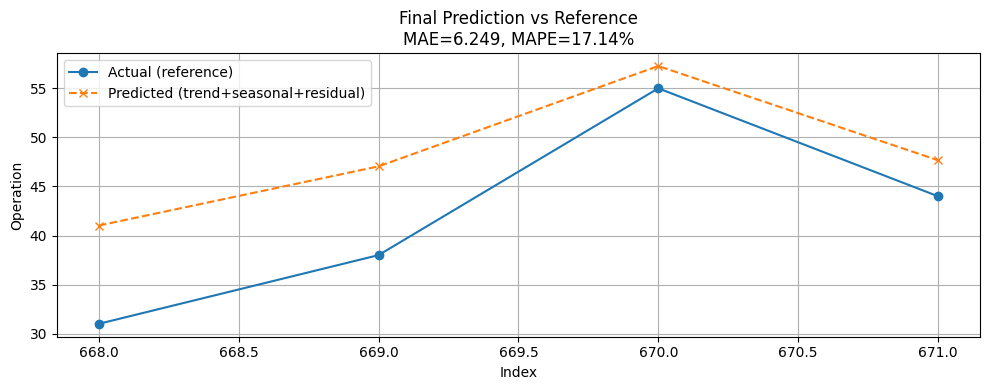

In [7]:
from pmdarima import auto_arima
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# 1. Extract residual series
residual_series = residual_df['residual'].astype(float)

# Define test_size (last points reserved for evaluation)
# Assume test_size is already defined; otherwise:
# test_size = 4  # or whatever you use

# -------------------------
# 1. Train / Test split on residuals
# -------------------------
residual_train = residual_series[:-test_size]
residual_test  = residual_series[-test_size:]

# -------------------------
# 2. Fit auto_arima ONLY on residual_train
# -------------------------
model_decomp = auto_arima(
    residual_train,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    d=0,          # fixed
    max_d=0,      # no differencing

    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=0,          # fixed
    max_D=0,      # no seasonal differencing

    seasonal=True,
    m=seasonal_period,

    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=False
)

print("\nBest model_decomp (fitted on residual_train):")
print(model_decomp.summary())

# -------------------------
# 3. Forecast residuals OUT-OF-SAMPLE for test_size steps
# -------------------------
residual_pred_test = model_decomp.predict(n_periods=test_size)
# Align as Series with same index as reference / residual_test
residual_pred_test = pd.Series(residual_pred_test, index=residual_test.index)

# -------------------------
# 4. Final reconstructed prediction
# -------------------------
# summed_up_array should correspond to (trend + seasonal) for the LAST test_size points
# Make sure its length == test_size and index aligns with reference
summed_up_series = pd.Series(summed_up_array, index=residual_test.index)

final_prediction = summed_up_series + residual_pred_test

# -------------------------
# 5. Evaluate against reference (original last values)
# -------------------------
mae_final = mean_absolute_error(reference.values, final_prediction.values)
mape_final = mean_absolute_percentage_error(reference.values, final_prediction.values) * 100

print("\nFINAL RECONSTRUCTION METRICS (true test)")
print(f"MAE           : {mae_final:.4f}")
print(f"MAPE_percent  : {mape_final:.4f}")

# -------------------------
# 6. Plot: Predicted vs Reference
# -------------------------
plt.figure(figsize=(10, 4))
plt.plot(reference.index, reference.values,
         marker='o', label='Actual (reference)')
plt.plot(reference.index, final_prediction.values,
         marker='x', linestyle='--',
         label='Predicted (trend+seasonal+residual)')

plt.title(f"Final Prediction vs Reference\nMAE={mae_final:.3f}, MAPE={mape_final:.2f}%")
plt.xlabel("Index")
plt.ylabel("Operation")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
model_decomp

RE WRITE THE MODEL DECOMPOSITION IF NECESSARY

In [ ]:
#model_decomp.order=(2,0,0)
#model_decomp.seasonal_order=(2,0,1,8)

In [ ]:
#model_decomp

DECOMPOSITION SARIMA

In [8]:
df=residual_df.copy()

In [9]:
train_data = df[:-test_len]  # Last 4 rows for testing
test_data = df[-test_len:]

MAE   (manual SARIMA): 6.4776
MAPE% (manual SARIMA): 62.9287


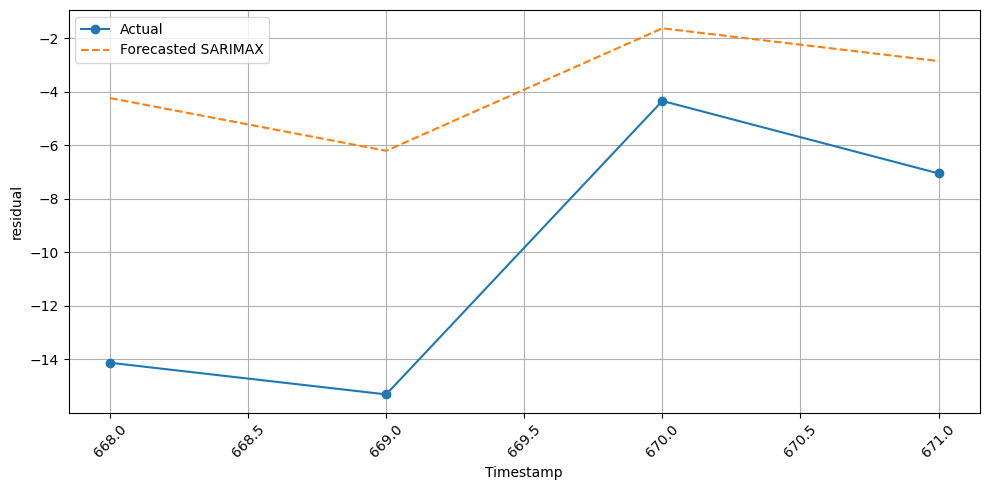

In [10]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# =========================================
# 1. MANUAL SARIMA/SARIMAX SPECIFICATION
# =========================================

model = SARIMAX(
    train_data['residual'],
    order=model_decomp.order,
    seasonal_order=model_decomp.seasonal_order,
)

# =========================================
# 2. Fit the model
# =========================================
sarimax_results = model.fit(disp=False)

# =========================================
# 3. Forecast for the test horizon
# =========================================
n_steps = len(test_data)

sarima_forecast = sarimax_results.get_forecast(steps=n_steps)
sarima_predictions = sarima_forecast.predicted_mean

# =========================================
# 4. Evaluation metrics
# =========================================
sarima_mae = mean_absolute_error(test_data['residual'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['residual'], sarima_predictions)

print(f"MAE   (manual SARIMA): {sarima_mae:.4f}")
print(f"MAPE% (manual SARIMA): {sarima_mape*100:.4f}")

# =========================================
# 5. Plot Actual vs Forecast
# =========================================
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['residual'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('residual')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


   Combined_Sum
0     41.155524
1     47.244098
2     57.522840
3     47.972566
MAE: 6.47
MAPE: 17.68%


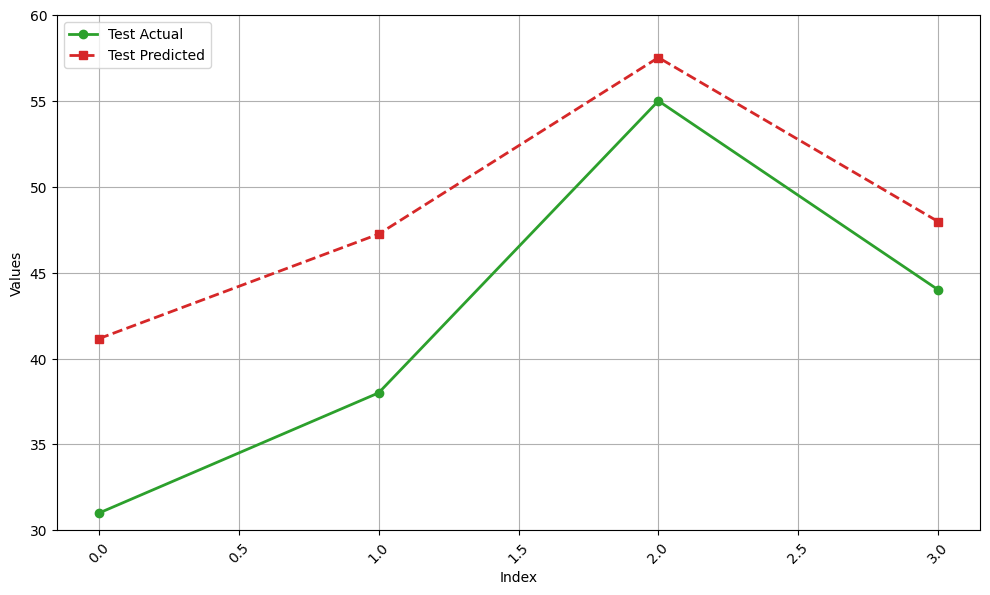

In [11]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(predicted.index, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

TOPOLOGICAL FEATURES

In [12]:
# Rename column 'residual' → 'Operation'
residual_df = residual_df.rename(columns={'residual': 'Operation'})
residual_df.index.name = None

In [13]:
df=residual_df.copy()

In [14]:
window_length = 24
window_size = 24
time_delay = 8
dimension = 3
stride = 1

In [15]:
import numpy as np
from gtda.time_series import SlidingWindow, TakensEmbedding
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import Scaler

# --- 1) Extract the time series as (n_timestamps, 1) ---
# df: your DataFrame, with a column 'Operation'
X = df['Operation'].to_numpy(dtype=float).reshape(-1, 1)   # shape: (n_timestamps, 1)

# --- 2) Sliding window: cut into overlapping windows ---
SW = SlidingWindow(size=window_size, stride=stride)
# Typical output shape: (n_windows, window_size, n_features)
X_sw = SW.fit_transform(X)

# For convenience, treat each window as an independent univariate series
n_windows, win_len, n_feat = X_sw.shape  # n_feat should be 1
X_windows = X_sw.reshape(n_windows, win_len)   # shape: (n_windows, window_size)

# --- 3) Takens embedding on each window ---
TE = TakensEmbedding(time_delay=time_delay, dimension=dimension)
# Input: (n_windows, window_size)
# Output: (n_windows, n_points, dimension)
X_te = TE.fit_transform(X_windows)

# --- 4) Vietoris–Rips persistence on embedded windows ---
VR = VietorisRipsPersistence(homology_dimensions=[0, 1])
# Input: (n_windows, n_points, dimension)
# Output: array of diagrams, one per window
diagrams = VR.fit_transform(X_te)

# --- 5) Scale persistence diagrams (normalization in diagram space) ---
scaler = Scaler()
scaled_diagrams = scaler.fit_transform(diagrams)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


EXTRACTING TDA FEATURES

In [16]:
# @title ONLY HEAT KERNEL FEATURES
import numpy as np
import pandas as pd
from gtda.diagrams import HeatKernel

# -------------------------------------------------------------------
# Helper: heat kernel feature extraction
# -------------------------------------------------------------------
def extract_heat_kernel_features(heat_kernel_features):
    """
    heat_kernel_features: array of shape
        (n_windows, 2, n_bins, n_bins) for H0 and H1

    Returns:
        DataFrame (n_windows, many_features)
        Columns:
            HK_L1_H0, HK_L2_H0,
            HK_Col0_L1_H0, HK_Col0_L2_H0, ..., HK_Col(N-1)_L1_H0, HK_Col(N-1)_L2_H0,
            HK_L1_H1, HK_L2_H1,
            HK_Col0_L1_H1, HK_Col0_L2_H1, ..., HK_Col(N-1)_L1_H1, HK_Col(N-1)_L2_H1
    """
    feature_list = []

    for i in range(heat_kernel_features.shape[0]):  # per window
        sample_feats = {}

        for dim_idx, hom_dim in enumerate(["H0", "H1"]):
            matrix = heat_kernel_features[i, dim_idx, :, :]  # shape: (n_bins, n_bins)

            # Global L1/L2 norms over full matrix
            sample_feats[f"HK_L1_{hom_dim}"] = np.sum(np.abs(matrix))
            sample_feats[f"HK_L2_{hom_dim}"] = np.sqrt(np.sum(matrix ** 2))

            # Per-column L1/L2 norms
            n_cols = matrix.shape[1]
            for col in range(n_cols):
                col_data = matrix[:, col]
                sample_feats[f"HK_Col{col}_L1_{hom_dim}"] = np.sum(np.abs(col_data))
                sample_feats[f"HK_Col{col}_L2_{hom_dim}"] = np.sqrt(
                    np.sum(col_data ** 2)
                )

        feature_list.append(sample_feats)

    heat_kernel_df = pd.DataFrame(feature_list)
    return heat_kernel_df


# -------------------------------------------------------------------
# Main: build HK-only windowed TDA feature matrix
# -------------------------------------------------------------------
def build_windowed_tda_feature_matrix(scaled_diagrams,
                                      heat_sigma=0.1,
                                      heat_bins=100):
    """
    HK-only version.

    Parameters
    ----------
    scaled_diagrams : array-like
        Persistence diagrams per window (compatible with gtda HeatKernel).
    heat_sigma : float
        Sigma parameter for HeatKernel.
    heat_bins : int
        Number of bins (n_bins) for HeatKernel.

    Returns
    -------
    heat_kernel_df : pd.DataFrame
        DataFrame of Heat Kernel features per window (HK-only).
    """

    # 1) Initialize HeatKernel transformer
    heat_kernel = HeatKernel(sigma=heat_sigma, n_bins=heat_bins, n_jobs=-1)

    # 2) Transform diagrams -> (n_windows, 2, n_bins, n_bins)
    heat_kernel_features = heat_kernel.fit_transform(scaled_diagrams)

    # 3) Extract HK-based features
    heat_kernel_df = extract_heat_kernel_features(heat_kernel_features)

    # 4) Clean: remove columns with NaN or ±inf anywhere (just in case)
    mask_good = ~heat_kernel_df.isin([np.inf, -np.inf]).any() & heat_kernel_df.notna().all()
    heat_kernel_df = heat_kernel_df.loc[:, mask_good]

    return heat_kernel_df


# Example usage (when you already have `scaled_diagrams`):
heat_kernel_df = build_windowed_tda_feature_matrix(scaled_diagrams,
                                                    heat_sigma=0.1,
                                                    heat_bins=100)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [17]:
# @title
heat_kernel_df

,HK_L1_H0,HK_L2_H0,HK_Col0_L1_H0,HK_Col0_L2_H0,HK_Col1_L1_H0,HK_Col1_L2_H0,HK_Col2_L1_H0,HK_Col2_L2_H0,HK_Col3_L1_H0,HK_Col3_L2_H0,...,HK_Col95_L1_H1,HK_Col95_L2_H1,HK_Col96_L1_H1,HK_Col96_L2_H1,HK_Col97_L1_H1,HK_Col97_L2_H1,HK_Col98_L1_H1,HK_Col98_L2_H1,HK_Col99_L1_H1,HK_Col99_L2_H1
0,18248.590575,684.311179,1379.996978,219.170327,1350.984090,214.716853,1269.639966,201.925135,1145.884477,182.280225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,18269.664378,593.513632,1380.027405,190.111365,1351.040302,186.244411,1269.725607,175.143246,1145.983784,158.096980,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,18302.374444,605.663764,1380.099380,193.918050,1351.165136,189.979982,1269.907750,178.666636,1146.189923,161.293482,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,17273.193796,666.800383,1304.880770,213.501305,1277.439489,209.166619,1200.527317,196.711833,1083.517274,177.584336,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17491.173109,585.334335,1307.126664,187.238349,1280.675891,183.456059,1204.578054,172.561701,1087.703436,155.822865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,17054.323739,776.692334,1329.803383,250.146415,1293.630039,244.621861,1209.852765,229.608745,1089.655950,206.932605,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
645,17095.511085,634.903468,1329.864238,204.889352,1293.742462,200.221056,1210.024047,187.796164,1089.854563,169.157284,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
646,18452.673761,777.190984,1382.289994,248.633576,1354.268178,243.610572,1273.734744,229.142976,1150.104038,206.913485,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
647,18255.303249,733.618661,1380.038526,234.912833,1351.052713,230.144232,1269.736468,216.441024,1145.987221,195.394443,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
# @title
final_combined_df=heat_kernel_df.copy()

In [ ]:
# @title ALL TDA FEATURES IF NECESSARY
import numpy as np
import pandas as pd
from gtda.diagrams import (
    PersistenceEntropy,
    Amplitude,
    BettiCurve,
    PersistenceLandscape,
    Silhouette,
    HeatKernel,
)
from scipy.stats import skew, kurtosis

# -------------------------------------------------------------------
# Small helpers
# -------------------------------------------------------------------
def safe_skew(x):
    if x.size < 2 or np.allclose(x, x[0]):
        return 0.0
    return float(skew(x, bias=False))

def safe_kurtosis(x):
    if x.size < 2 or np.allclose(x, x[0]):
        return 0.0
    return float(kurtosis(x, bias=False, fisher=True))

def safe_gini(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return 0.0
    x = np.abs(x)
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = x.size
    cum = np.cumsum(x)
    g = (n + 1 - 2.0 * np.sum(cum) / cum[-1]) / n
    return float(g)

def safe_quantile(x, q):
    if x.size == 0:
        return 0.0
    return float(np.quantile(x, q))

def safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 2 or y.size < 2:
        return 0.0
    if np.allclose(x, x[0]) or np.allclose(y, y[0]):
        return 0.0
    return float(np.corrcoef(x, y)[0, 1])

def safe_ratio(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        r = np.where(den != 0, num / den, 0.0)
    return r

# -------------------------------------------------------------------
# Helper: Carlsson features
# -------------------------------------------------------------------
def compute_carlsson_features(births, deaths, fn_max=5):
    """Compute Carlsson-type features f1..f5 for a single diagram."""
    if len(births) == 0:
        return [0.0] * fn_max

    lifetimes = deaths - births
    d_max = np.max(deaths) if len(deaths) > 0 else 0.0

    f1 = np.sum(births * lifetimes) if fn_max >= 1 else None
    f2 = np.sum((d_max - deaths) * lifetimes) if fn_max >= 2 else None
    f3 = np.sum((births ** 2) * (lifetimes ** 4)) if fn_max >= 3 else None
    f4 = np.sum(((d_max - deaths) ** 2) * (lifetimes ** 4)) if fn_max >= 4 else None
    f5 = np.max(lifetimes) if (fn_max >= 5 and len(lifetimes) > 0) else None

    values = [f1, f2, f3, f4, f5][:fn_max]
    return [v if v is not None else 0.0 for v in values]


# -------------------------------------------------------------------
# Helper: Heat kernel feature extraction (compressed, rich)
# -------------------------------------------------------------------
def extract_heat_kernel_features(heat_kernel_features, eps=1e-6, max_singular_values=3):
    """
    heat_kernel_features: array of shape
        (n_windows, 2, n_bins, n_bins) for H0 and H1

    Returns:
        DataFrame (n_windows, many_features)
    """
    feature_list = []

    for i in range(heat_kernel_features.shape[0]):  # per window
        sample_feats = {}

        for dim_idx, hom_dim in enumerate(["H0", "H1"]):
            matrix = heat_kernel_features[i, dim_idx, :, :]  # shape: (n_bins, n_bins)
            vals = matrix.flatten()
            abs_vals = np.abs(vals)

            # Global L1/L2
            L1 = float(np.sum(abs_vals))
            L2 = float(np.sqrt(np.sum(vals ** 2)))
            sample_feats[f"HK_L1_{hom_dim}"] = L1
            sample_feats[f"HK_L2_{hom_dim}"] = L2

            # Basic stats
            sample_feats[f"HK_mean_{hom_dim}"] = float(np.mean(vals)) if vals.size > 0 else 0.0
            sample_feats[f"HK_median_{hom_dim}"] = float(np.median(vals)) if vals.size > 0 else 0.0
            sample_feats[f"HK_std_{hom_dim}"] = float(np.std(vals)) if vals.size > 0 else 0.0
            sample_feats[f"HK_var_{hom_dim}"] = float(np.var(vals)) if vals.size > 0 else 0.0
            sample_feats[f"HK_skew_{hom_dim}"] = safe_skew(vals)
            sample_feats[f"HK_kurt_{hom_dim}"] = safe_kurtosis(vals)

            # Energy (Frobenius^2) and sparsity
            energy = float(np.sum(vals ** 2))
            sample_feats[f"HK_energy_{hom_dim}"] = energy
            sparsity_ratio = float(np.mean(abs_vals < eps)) if vals.size > 0 else 0.0
            sample_feats[f"HK_sparsity_ratio_{hom_dim}"] = sparsity_ratio

            # Entropy (using |vals| normalized as probabilities)
            if L1 > 0:
                p = abs_vals / L1
                # avoid log(0)
                p_safe = p[p > 0]
                entropy_val = -float(np.sum(p_safe * np.log(p_safe)))
            else:
                entropy_val = 0.0
            sample_feats[f"HK_entropy_{hom_dim}"] = entropy_val

            # Row/column aggregates (using L1 per row/col)
            row_sums = np.sum(abs_vals.reshape(matrix.shape), axis=1)
            col_sums = np.sum(abs_vals.reshape(matrix.shape), axis=0)

            for label, arr in [("row", row_sums), ("col", col_sums)]:
                if arr.size > 0:
                    sample_feats[f"HK_{label}_L1_mean_{hom_dim}"] = float(np.mean(arr))
                    sample_feats[f"HK_{label}_L1_std_{hom_dim}"] = float(np.std(arr))
                    sample_feats[f"HK_{label}_L1_min_{hom_dim}"] = float(np.min(arr))
                    sample_feats[f"HK_{label}_L1_max_{hom_dim}"] = float(np.max(arr))
                else:
                    sample_feats[f"HK_{label}_L1_mean_{hom_dim}"] = 0.0
                    sample_feats[f"HK_{label}_L1_std_{hom_dim}"] = 0.0
                    sample_feats[f"HK_{label}_L1_min_{hom_dim}"] = 0.0
                    sample_feats[f"HK_{label}_L1_max_{hom_dim}"] = 0.0

            # Symmetry measure: ||HK - HK^T||_F
            sym_diff = matrix - matrix.T
            sym_F = float(np.sqrt(np.sum(sym_diff ** 2)))
            sample_feats[f"HK_symmetry_F_{hom_dim}"] = sym_F

            # SVD singular values (PCA-like compression)
            try:
                s = np.linalg.svd(matrix, compute_uv=False)
                for k in range(max_singular_values):
                    val = float(s[k]) if k < len(s) else 0.0
                    sample_feats[f"HK_SV{k+1}_{hom_dim}"] = val
            except np.linalg.LinAlgError:
                for k in range(max_singular_values):
                    sample_feats[f"HK_SV{k+1}_{hom_dim}"] = 0.0

            # Graph Laplacian spectral features (on |HK|)
            w = np.abs(matrix)
            deg = np.sum(w, axis=1)
            L = np.diag(deg) - w
            try:
                eigvals = np.linalg.eigvalsh(L)
                eigvals = np.real(eigvals)
                if eigvals.size > 0:
                    eig_min = float(np.min(eigvals))
                    eig_max = float(np.max(eigvals))
                    trace_L = float(np.trace(L))
                    fro_L = float(np.sqrt(np.sum(L ** 2)))
                else:
                    eig_min = eig_max = trace_L = fro_L = 0.0
            except np.linalg.LinAlgError:
                eig_min = eig_max = trace_L = fro_L = 0.0

            sample_feats[f"HK_Laplacian_eig_min_{hom_dim}"] = eig_min
            sample_feats[f"HK_Laplacian_eig_max_{hom_dim}"] = eig_max
            sample_feats[f"HK_Laplacian_trace_{hom_dim}"] = trace_L
            sample_feats[f"HK_Laplacian_fro_{hom_dim}"] = fro_L

        feature_list.append(sample_feats)

    heat_kernel_df = pd.DataFrame(feature_list)
    return heat_kernel_df


# -------------------------------------------------------------------
# Helper: Betti / landscape / silhouette full features
# -------------------------------------------------------------------
def compute_curve_features(curve_array, prefix):
    """
    curve_array: shape (n_windows, 2, n_points)   (H0, H1)
    prefix: string prefix for column names (e.g. 'betti', 'landscape', 'silhouette')

    Returns DataFrame with columns:
        L1, L2, max, mean, median, std, var, skew, kurt,
        AUC, gini, nonzero_count, sparsity, for H0 and H1.
    """
    n_windows = curve_array.shape[0]

    feats = {}

    for hom_idx, hom_dim in enumerate(["H0", "H1"]):
        feats[f"{prefix}_L1_{hom_dim}"] = []
        feats[f"{prefix}_L2_{hom_dim}"] = []
        feats[f"{prefix}_max_{hom_dim}"] = []
        feats[f"{prefix}_mean_{hom_dim}"] = []
        feats[f"{prefix}_median_{hom_dim}"] = []
        feats[f"{prefix}_std_{hom_dim}"] = []
        feats[f"{prefix}_var_{hom_dim}"] = []
        feats[f"{prefix}_skew_{hom_dim}"] = []
        feats[f"{prefix}_kurt_{hom_dim}"] = []
        feats[f"{prefix}_AUC_{hom_dim}"] = []
        feats[f"{prefix}_gini_{hom_dim}"] = []
        feats[f"{prefix}_nonzero_count_{hom_dim}"] = []
        feats[f"{prefix}_sparsity_{hom_dim}"] = []

    for i in range(n_windows):
        for hom_idx, hom_dim in enumerate(["H0", "H1"]):
            v = curve_array[i, hom_idx, :]
            v = np.asarray(v, dtype=float)
            if v.size == 0:
                L1 = L2 = vmax = vmean = vmed = vstd = vvar = vaskew = vakurt = 0.0
                auc = g = 0.0
                nonzero = 0
                sparsity = 0.0
            else:
                L1 = float(np.sum(np.abs(v)))
                L2 = float(np.sqrt(np.sum(v ** 2)))
                vmax = float(np.max(v))
                vmean = float(np.mean(v))
                vmed = float(np.median(v))
                vstd = float(np.std(v))
                vvar = float(np.var(v))
                vaskew = safe_skew(v)
                vakurt = safe_kurtosis(v)
                # AUC ~ integral over discrete grid
                auc = float(np.trapz(v))
                g = safe_gini(v)
                nonzero = int(np.count_nonzero(v))
                sparsity = float(1.0 - nonzero / v.size)

            feats[f"{prefix}_L1_{hom_dim}"].append(L1)
            feats[f"{prefix}_L2_{hom_dim}"].append(L2)
            feats[f"{prefix}_max_{hom_dim}"].append(vmax)
            feats[f"{prefix}_mean_{hom_dim}"].append(vmean)
            feats[f"{prefix}_median_{hom_dim}"].append(vmed)
            feats[f"{prefix}_std_{hom_dim}"].append(vstd)
            feats[f"{prefix}_var_{hom_dim}"].append(vvar)
            feats[f"{prefix}_skew_{hom_dim}"].append(vaskew)
            feats[f"{prefix}_kurt_{hom_dim}"].append(vakurt)
            feats[f"{prefix}_AUC_{hom_dim}"].append(auc)
            feats[f"{prefix}_gini_{hom_dim}"].append(g)
            feats[f"{prefix}_nonzero_count_{hom_dim}"].append(nonzero)
            feats[f"{prefix}_sparsity_{hom_dim}"].append(sparsity)

    df = pd.DataFrame(feats)
    return df


# -------------------------------------------------------------------
# Helper: flatten simple vector features
# -------------------------------------------------------------------
def flatten_features_to_df(features_array, prefix):
    """
    features_array: np.ndarray of shape (n_windows, ...)
    prefix: base name for columns
    """
    flattened = features_array.reshape(features_array.shape[0], -1)
    cols = [f"{prefix}_{i}" for i in range(flattened.shape[1])]
    return pd.DataFrame(flattened, columns=cols)


# -------------------------------------------------------------------
# Helper: diagram statistics + Carlsson features + shape features
# -------------------------------------------------------------------
def extract_diagram_statistics(scaled_diagrams, fn_max=5):
    """
    scaled_diagrams: array-like of diagrams, each of shape (n_points, 3)
                     columns: [birth, death, homology_dim]
    Returns:
        features_df: DataFrame with per-window summary stats + Carlsson features.
    """
    n_windows = len(scaled_diagrams)
    features = {}

    for dim in [0, 1]:  # H0, H1
        # filter diagrams by dimension
        filtered_diagrams = [
            diagram[diagram[:, 2] == dim] for diagram in scaled_diagrams
        ]

        for i, diagram_dim in enumerate(filtered_diagrams):
            lifetimes = (
                diagram_dim[:, 1] - diagram_dim[:, 0]
                if len(diagram_dim) > 0
                else np.array([])
            )
            births = diagram_dim[:, 0] if len(diagram_dim) > 0 else np.array([])
            deaths = diagram_dim[:, 1] if len(diagram_dim) > 0 else np.array([])

            sample_key = f"sample_{i}"

            if sample_key not in features:
                features[sample_key] = {}

            # Basic counts
            features[sample_key][f"dim_{dim}_num_features"] = int(len(lifetimes))
            features[sample_key][f"dim_{dim}_sum_lifetimes"] = float(np.sum(lifetimes))

            if len(lifetimes) > 0:
                # Lifetime statistics
                max_life = float(np.max(lifetimes))
                mean_life = float(np.mean(lifetimes))
                median_life = float(np.median(lifetimes))
                std_life = float(np.std(lifetimes))
                var_life = float(np.var(lifetimes))
                min_life = float(np.min(lifetimes))

                features[sample_key][f"dim_{dim}_max_lifetime"] = max_life
                features[sample_key][f"dim_{dim}_mean_lifetime"] = mean_life
                features[sample_key][f"dim_{dim}_median_lifetime"] = median_life
                features[sample_key][f"dim_{dim}_std_lifetime"] = std_life
                features[sample_key][f"dim_{dim}_variance_lifetime"] = var_life
                features[sample_key][f"dim_{dim}_min_lifetime"] = min_life

                # Lifetime shape: skew, kurtosis, IQR, CV, Gini, tail, top-k
                features[sample_key][f"dim_{dim}_skew_lifetime"] = safe_skew(lifetimes)
                features[sample_key][f"dim_{dim}_kurt_lifetime"] = safe_kurtosis(lifetimes)
                features[sample_key][f"dim_{dim}_IQR_lifetime"] = float(
                    safe_quantile(lifetimes, 0.75) - safe_quantile(lifetimes, 0.25)
                )
                features[sample_key][f"dim_{dim}_CV_lifetime"] = (
                    float(std_life / mean_life) if mean_life != 0 else 0.0
                )
                features[sample_key][f"dim_{dim}_Gini_lifetime"] = safe_gini(lifetimes)
                features[sample_key][f"dim_{dim}_Q90_lifetime"] = safe_quantile(
                    lifetimes, 0.90
                )
                features[sample_key][f"dim_{dim}_Q95_lifetime"] = safe_quantile(
                    lifetimes, 0.95
                )
                features[sample_key][f"dim_{dim}_Q99_lifetime"] = safe_quantile(
                    lifetimes, 0.99
                )

                # Top-k lifetimes and shares
                sorted_life = np.sort(lifetimes)[::-1]
                for k in [1, 3, 5]:
                    if len(sorted_life) >= k:
                        topk = sorted_life[:k]
                        topk_sum = float(np.sum(topk))
                        features[sample_key][f"dim_{dim}_top{k}_lifetime_sum"] = topk_sum
                        features[sample_key][f"dim_{dim}_top{k}_lifetime_share"] = (
                            float(topk_sum / np.sum(lifetimes))
                            if np.sum(lifetimes) != 0
                            else 0.0
                        )
                    else:
                        features[sample_key][f"dim_{dim}_top{k}_lifetime_sum"] = 0.0
                        features[sample_key][f"dim_{dim}_top{k}_lifetime_share"] = 0.0

                # Persistence ratios
                sum_life = float(np.sum(lifetimes))
                max_ratio = float(max_life / sum_life) if sum_life != 0 else 0.0
                features[sample_key][f"dim_{dim}_max_lifetime_ratio"] = max_ratio

                # Birth/death statistics
                features[sample_key][f"dim_{dim}_sum_birth_times"] = float(np.sum(births))
                features[sample_key][f"dim_{dim}_mean_birth_time"] = float(np.mean(births))
                features[sample_key][f"dim_{dim}_sum_death_times"] = float(np.sum(deaths))
                features[sample_key][f"dim_{dim}_mean_death_time"] = float(np.mean(deaths))

                # Birth/death shape
                features[sample_key][f"dim_{dim}_range_birth"] = float(
                    np.max(births) - np.min(births)
                )
                features[sample_key][f"dim_{dim}_range_death"] = float(
                    np.max(deaths) - np.min(deaths)
                )
                features[sample_key][f"dim_{dim}_skew_birth"] = safe_skew(births)
                features[sample_key][f"dim_{dim}_kurt_birth"] = safe_kurtosis(births)
                features[sample_key][f"dim_{dim}_skew_death"] = safe_skew(deaths)
                features[sample_key][f"dim_{dim}_kurt_death"] = safe_kurtosis(deaths)

                # Birth-death correlation
                features[sample_key][f"dim_{dim}_birth_death_corr"] = safe_corr(
                    births, deaths
                )

                # Persistence center of mass & distance to diagonal
                mean_birth = features[sample_key][f"dim_{dim}_mean_birth_time"]
                mean_death = features[sample_key][f"dim_{dim}_mean_death_time"]
                features[sample_key][f"dim_{dim}_COM_birth"] = mean_birth
                features[sample_key][f"dim_{dim}_COM_death"] = mean_death
                features[sample_key][f"dim_{dim}_COM_diag_dist"] = float(
                    mean_death - mean_birth
                )

                # Carlsson features
                f_vals = compute_carlsson_features(births, deaths, fn_max=fn_max)
                for j, fv in enumerate(f_vals, start=1):
                    features[sample_key][f"dim_{dim}_carlsson_f{j}"] = float(fv)

            else:
                # Empty diagram → set everything to 0
                for metric in [
                    "max_lifetime",
                    "mean_lifetime",
                    "median_lifetime",
                    "std_lifetime",
                    "variance_lifetime",
                    "min_lifetime",
                    "skew_lifetime",
                    "kurt_lifetime",
                    "IQR_lifetime",
                    "CV_lifetime",
                    "Gini_lifetime",
                    "Q90_lifetime",
                    "Q95_lifetime",
                    "Q99_lifetime",
                    "sum_birth_times",
                    "mean_birth_time",
                    "sum_death_times",
                    "mean_death_time",
                    "range_birth",
                    "range_death",
                    "skew_birth",
                    "kurt_birth",
                    "skew_death",
                    "kurt_death",
                    "birth_death_corr",
                    "COM_birth",
                    "COM_death",
                    "COM_diag_dist",
                    "max_lifetime_ratio",
                ]:
                    features[sample_key][f"dim_{dim}_{metric}"] = 0.0

                for k in [1, 3, 5]:
                    features[sample_key][f"dim_{dim}_top{k}_lifetime_sum"] = 0.0
                    features[sample_key][f"dim_{dim}_top{k}_lifetime_share"] = 0.0

                for j in range(1, fn_max + 1):
                    features[sample_key][f"dim_{dim}_carlsson_f{j}"] = 0.0

    features_df = pd.DataFrame.from_dict(features, orient="index")
    features_df.reset_index(drop=True, inplace=True)
    return features_df


# -------------------------------------------------------------------
# Main: build full windowed TDA feature matrix
# -------------------------------------------------------------------
def build_windowed_tda_feature_matrix(scaled_diagrams, heat_sigma=0.1, heat_bins=100, fn_max=5):
    """
    scaled_diagrams: array-like of persistence diagrams per window
    Returns:
        final_combined_df: DataFrame of all TDA features per window
    """

    # 1) Initialize feature extractors
    persistence_entropy = PersistenceEntropy()
    amplitude_bottleneck = Amplitude(metric="bottleneck")
    amplitude_wasserstein = Amplitude(metric="wasserstein")
    amplitude_landscape = Amplitude(metric="landscape")
    betti_curve = BettiCurve()
    persistence_landscape = PersistenceLandscape()
    silhouette = Silhouette()
    heat_kernel = HeatKernel(sigma=heat_sigma, n_bins=heat_bins, n_jobs=-1)

    # 2) Transform diagrams
    entropy_features = persistence_entropy.fit_transform(scaled_diagrams)
    amplitude_bottleneck_features = amplitude_bottleneck.fit_transform(scaled_diagrams)
    amplitude_wasserstein_features = amplitude_wasserstein.fit_transform(scaled_diagrams)
    amplitude_landscape_features = amplitude_landscape.fit_transform(scaled_diagrams)
    betti_features = betti_curve.fit_transform(scaled_diagrams)
    landscape_features = persistence_landscape.fit_transform(scaled_diagrams)
    silhouette_features = silhouette.fit_transform(scaled_diagrams)
    heat_kernel_features = heat_kernel.fit_transform(scaled_diagrams)

    # 3) Build DataFrames from each group

    # 3.1 Betti curves, landscapes, silhouettes → rich summaries
    betti_df = compute_curve_features(betti_features, prefix="betti")
    landscape_df = compute_curve_features(landscape_features, prefix="landscape")
    silhouette_df = compute_curve_features(silhouette_features, prefix="silhouette")

    # 3.2 Flattenable features: entropy and amplitudes
    entropy_df = flatten_features_to_df(entropy_features, prefix="entropy")
    amplitude_bottleneck_df = flatten_features_to_df(
        amplitude_bottleneck_features, prefix="amplitude_bottleneck"
    )
    amplitude_wasserstein_df = flatten_features_to_df(
        amplitude_wasserstein_features, prefix="amplitude_wasserstein"
    )
    amplitude_landscape_df = flatten_features_to_df(
        amplitude_landscape_features, prefix="amplitude_landscape"
    )

    # 3.3 Heat kernel features (compressed)
    heat_kernel_df = extract_heat_kernel_features(heat_kernel_features)

    # 4) Combine all "simple" features
    combined_df = pd.concat(
        [
            entropy_df,
            amplitude_bottleneck_df,
            amplitude_wasserstein_df,
            amplitude_landscape_df,
            betti_df,
            landscape_df,
            silhouette_df,
            heat_kernel_df,
        ],
        axis=1,
    )

    # 5) Add diagram statistics (lifetimes, birth/death stats, Carlsson + shape)
    stats_df = extract_diagram_statistics(scaled_diagrams, fn_max=fn_max)

    # 6) Cross-homology features (H1 vs H0)
    cross_df = pd.DataFrame()
    # Lifetime sum ratio H1/H0
    if (
        "dim_1_sum_lifetimes" in stats_df.columns
        and "dim_0_sum_lifetimes" in stats_df.columns
    ):
        cross_df["H1_over_H0_sum_lifetimes"] = safe_ratio(
            stats_df["dim_1_sum_lifetimes"].values,
            stats_df["dim_0_sum_lifetimes"].values,
        )
    else:
        cross_df["H1_over_H0_sum_lifetimes"] = 0.0

    # Max lifetime ratio H1/H0
    if (
        "dim_1_max_lifetime" in stats_df.columns
        and "dim_0_max_lifetime" in stats_df.columns
    ):
        cross_df["H1_over_H0_max_lifetime"] = safe_ratio(
            stats_df["dim_1_max_lifetime"].values,
            stats_df["dim_0_max_lifetime"].values,
        )
    else:
        cross_df["H1_over_H0_max_lifetime"] = 0.0

    # Betti AUC ratio H1/H0 (if available)
    if (
        "betti_AUC_H1" in combined_df.columns
        and "betti_AUC_H0" in combined_df.columns
    ):
        cross_df["H1_over_H0_betti_AUC"] = safe_ratio(
            combined_df["betti_AUC_H1"].values,
            combined_df["betti_AUC_H0"].values,
        )
    else:
        cross_df["H1_over_H0_betti_AUC"] = 0.0

    # Entropy difference H1 - H0 (using entropy_0, entropy_1 if they exist)
    # PersistenceEntropy returns one feature per homology dimension
    if "entropy_0" in entropy_df.columns and "entropy_1" in entropy_df.columns:
        cross_df["entropy_diff_H1_minus_H0"] = (
            entropy_df["entropy_1"].values - entropy_df["entropy_0"].values
        )
    else:
        cross_df["entropy_diff_H1_minus_H0"] = 0.0

    # 7) Final concatenation
    final_combined_df = pd.concat(
        [
            combined_df.reset_index(drop=True),
            stats_df.reset_index(drop=True),
            cross_df.reset_index(drop=True),
        ],
        axis=1,
    )

    # 8) Remove columns with NaN or ±inf anywhere
    mask_good = ~final_combined_df.isin([np.inf, -np.inf]).any() & final_combined_df.notna().all()
    final_combined_df = final_combined_df.loc[:, mask_good]

    return final_combined_df

final_combined_df_2 = build_windowed_tda_feature_matrix(
    scaled_diagrams,
    heat_sigma=0.1,
    heat_bins=30,   # make it smaller for quick tests
    fn_max=5
)


In [ ]:
# @title
final_combined_df_2

In [ ]:
# @title
import pandas as pd

# 1. Column-wise concat (indices assumed to be aligned)
final_combined_df = pd.concat(
    [final_combined_df_1, final_combined_df_2],
    axis=1
)

# 2. Fix duplicate column names by adding 1,2,3,...
cols = final_combined_df.columns.tolist()
new_cols = []
counts = {}

for col in cols:
    if col not in counts:
        # first time we see this column name -> keep as is
        counts[col] = 0
        new_cols.append(col)
    else:
        # we've seen this name before -> increment counter and append number
        counts[col] += 1
        new_cols.append(f"{col}{counts[col]}")  # e.g. "Operation1", "Operation2"

final_combined_df.columns = new_cols

print(final_combined_df.shape)
print(final_combined_df.columns)




SARIMAX WITH FEATURES

In [19]:
# Dropping columns with low variance from final_combined_df
if 'final_combined_df' in locals():
    # Calculate variance of each column
    variance = final_combined_df.var()

    # Threshold for low variance (can be adjusted)
    low_variance_threshold = 0.01  # Example: close to zero variance

    # Identify columns with variance below the threshold
    low_variance_columns = variance[variance < low_variance_threshold].index

    # Drop low variance columns
    final_combined_df_cleaned = final_combined_df.drop(columns=low_variance_columns)

In [20]:
data=final_combined_df_cleaned

In [21]:
data

,HK_L1_H0,HK_L2_H0,HK_Col0_L1_H0,HK_Col0_L2_H0,HK_Col1_L1_H0,HK_Col1_L2_H0,HK_Col2_L1_H0,HK_Col2_L2_H0,HK_Col3_L1_H0,HK_Col3_L2_H0,...,HK_Col95_L1_H1,HK_Col95_L2_H1,HK_Col96_L1_H1,HK_Col96_L2_H1,HK_Col97_L1_H1,HK_Col97_L2_H1,HK_Col98_L1_H1,HK_Col98_L2_H1,HK_Col99_L1_H1,HK_Col99_L2_H1
0,18248.590575,684.311179,1379.996978,219.170327,1350.984090,214.716853,1269.639966,201.925135,1145.884477,182.280225,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,18269.664378,593.513632,1380.027405,190.111365,1351.040302,186.244411,1269.725607,175.143246,1145.983784,158.096980,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,18302.374444,605.663764,1380.099380,193.918050,1351.165136,189.979982,1269.907750,178.666636,1146.189923,161.293482,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,17273.193796,666.800383,1304.880770,213.501305,1277.439489,209.166619,1200.527317,196.711833,1083.517274,177.584336,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,17491.173109,585.334335,1307.126664,187.238349,1280.675891,183.456059,1204.578054,172.561701,1087.703436,155.822865,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,17054.323739,776.692334,1329.803383,250.146415,1293.630039,244.621861,1209.852765,229.608745,1089.655950,206.932605,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
645,17095.511085,634.903468,1329.864238,204.889352,1293.742462,200.221056,1210.024047,187.796164,1089.854563,169.157284,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
646,18452.673761,777.190984,1382.289994,248.633576,1354.268178,243.610572,1273.734744,229.142976,1150.104038,206.913485,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
647,18255.303249,733.618661,1380.038526,234.912833,1351.052713,230.144232,1269.736468,216.441024,1145.987221,195.394443,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
# Identify columns with inf, -inf, or NaN values
cols_with_invalid_values = data.columns[data.isin([np.inf, -np.inf]).any() | data.isna().any()]

# Replace inf and -inf with NaN first
data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with column mean
data[cols_with_invalid_values] = data[cols_with_invalid_values].apply(lambda col: col.fillna(col.mean()), axis=0)

In [23]:
simplified_df=data

In [24]:
# Adjust the indices of the feature dataset for regression analysis
regression_features_df = simplified_df[:-1].reset_index(drop=True)
regression_target_series = df['Operation'][window_size:].reset_index(drop=True)

# Combine features and target into a single dataset for regression analysis
regression_dataset = regression_features_df.copy()
regression_dataset['Target'] = regression_target_series

In [25]:
# Adjust the indices of the feature dataset for regression analysis
regression_features_df = simplified_df[:-1].reset_index(drop=True)
regression_target_series = df['Operation'][window_size:].reset_index(drop=True)

# Combine features and target into a single dataset for regression analysis
regression_dataset = regression_features_df.copy()
regression_dataset['Target'] = regression_target_series

In [26]:
df2=regression_dataset

In [27]:
from sklearn.ensemble import RandomForestRegressor
from feature_engine.selection import SmartCorrelatedSelection

In [28]:
# Assume the last column is the target variable (modify if needed)
target_column = "Target"  # Change if your target column has a different name
X = df2.drop(columns=[target_column])  # Extract feature columns
y = df2[target_column]  # Define the target variable

# Initialize SmartCorrelatedSelection for regression
tr = SmartCorrelatedSelection(
    variables=None,  # Apply to all numeric features
    method="pearson",  # Pearson correlation method
    threshold=0.99,  # Correlation threshold
    missing_values="raise",  # Raise error if missing values exist
    selection_method="model_performance",  # Use model performance to select features
    estimator=RandomForestRegressor(random_state=1, n_estimators=100),  # RandomForest for regression
    scoring="r2",  # Use R² as the evaluation metric
    cv=3  # 3-fold cross-validation
)

# Fit and transform the dataset to select best features
X_selected = tr.fit_transform(X, y)

# Reconstruct df2 with selected features and target variable
df2 = pd.concat([X_selected, y], axis=1)

In [29]:
from sklearn.preprocessing import MinMaxScaler

# Separate features and target
features = df2.drop(columns=["Target"])
target = df2["Target"]

# Apply scaling only to features
scaler = MinMaxScaler()
features_scaled = pd.DataFrame(scaler.fit_transform(features), columns=features.columns, index=features.index)

# Recombine scaled features with the original Target
df2_scaled = pd.concat([features_scaled, target], axis=1)

In [30]:
df2_scaled

,HK_L1_H0,HK_Col1_L2_H0,HK_Col3_L1_H0,HK_Col3_L2_H0,HK_Col6_L1_H0,HK_Col6_L2_H0,HK_Col7_L1_H0,HK_Col7_L2_H0,HK_Col8_L1_H0,HK_Col9_L1_H0,...,HK_Col77_L1_H1,HK_Col80_L1_H1,HK_Col83_L1_H1,HK_Col85_L1_H1,HK_Col88_L2_H1,HK_Col89_L1_H1,HK_Col91_L1_H1,HK_Col95_L1_H1,HK_Col96_L1_H1,Target
0,0.975768,0.408936,0.992587,0.436061,0.869928,0.308036,0.543133,0.171927,0.238590,0.184103,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.002405
1,0.977579,0.224366,0.992748,0.256994,0.867633,0.141375,0.536511,0.074093,0.225580,0.165758,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.299383
2,0.980391,0.248581,0.993083,0.280663,0.863809,0.163396,0.525737,0.085264,0.205097,0.137899,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.641235
3,0.891929,0.372957,0.891307,0.401290,0.744359,0.275663,0.427938,0.151530,0.146308,0.117696,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-4.510812
4,0.910665,0.206291,0.898105,0.240155,0.721481,0.124077,0.366304,0.056699,0.044159,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.709613
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
643,0.728239,0.387580,0.752953,0.399299,0.685445,0.341966,0.463318,0.253812,0.255575,0.239976,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.777447
644,0.873117,0.602793,0.901276,0.618601,0.818325,0.497677,0.549715,0.308677,0.298433,0.263556,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-14.122549
645,0.876657,0.314968,0.901598,0.338891,0.813786,0.241165,0.536624,0.160176,0.272771,0.227490,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-15.305862
646,0.993309,0.596237,0.999439,0.618460,0.848263,0.476684,0.485211,0.264039,0.144599,0.079328,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-4.336448


In [31]:
df=df2_scaled.copy()

In [32]:
train_data = df[:-test_len]  # Last 4 rows for testing
test_data = df[-test_len:]

In [33]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [34]:
exog_train=selected_columns_train
exog_test=selected_columns_test

In [35]:
model_decomp

,order,"(1, ...)"
,seasonal_order,"(2, ...)"
,start_params,None
,method,'lbfgs'
,maxiter,50
,suppress_warnings,True
,out_of_sample_size,0
,scoring,'mse'
,scoring_args,{}
,trend,None
,with_intercept,True


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


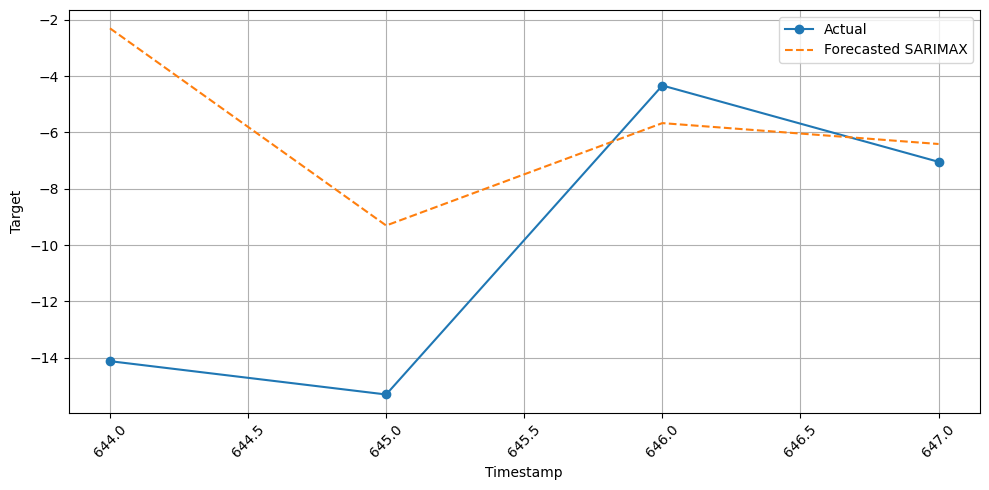

In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'],
                order=model_decomp.order,
                seasonal_order=model_decomp.seasonal_order,
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [37]:
# Output the MSE and MAPE values
sarima_mse, sarima_mape

(4.9458342695433135, 0.4065755963246732)

   Combined_Sum
0     43.079285
1     44.137602
2     53.473533
3     44.407666
MAE: 5.04
MAPE: 14.70%


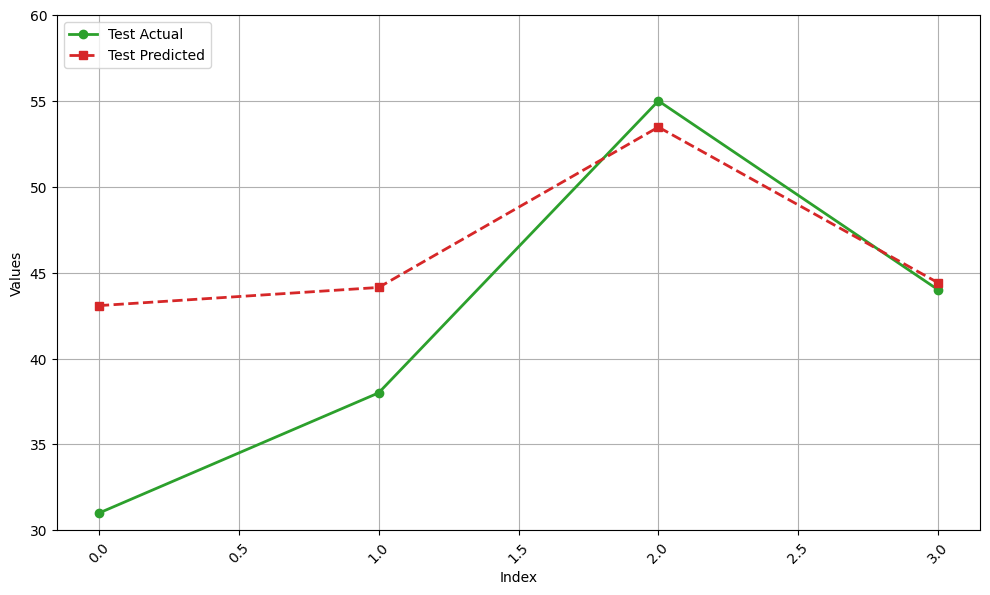

In [38]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(predicted.index, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()

IMPROVED RESULT BY USING HEAT KERNEL ONLY.

IMPROVING BY FEATURES SELECTION

In [ ]:
df=df2_scaled.copy()

In [ ]:
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.utils import resample

import warnings
import multiprocessing
from joblib import Parallel, delayed

warnings.filterwarnings("ignore")



# Load dataset

target_column = "Target"
exog_columns = [col for col in df.columns if col != target_column]

# Split into training
train_df = df.iloc[:-4]
X_train = train_df[exog_columns]
y_train = train_df[target_column]

# SARIMAX p-value extractor
def get_p_values(X, y):
    try:
        model = SARIMAX(y,
                        order=model_decomp.order,
                        seasonal_order=model_decomp.seasonal_order,
                        exog=X)
        result = model.fit(disp=False)
        return result.pvalues.loc[X.columns]
    except Exception as e:
        print("SARIMAX fit error:", e)
        return pd.Series([1.0] * X.shape[1], index=X.columns)

# Model AIC calculator
def compute_aic(feature_set):
    try:
        model = SARIMAX(y_train,
                        order=model_decomp.order,
                        seasonal_order=model_decomp.seasonal_order,
                        exog=X_train[list(feature_set)])
        result = model.fit(disp=False)
        return (feature_set, result.aic)
    except:
        return (feature_set, np.inf)

# RFE parameters
selected_features = exog_columns.copy()
step2 = 5

# RFE Loop
while True:
    p_values = get_p_values(X_train[selected_features], y_train)

    # Features with p > 0.05
    worst_candidates = p_values[p_values > 0.05]

    # Stopping criterion
    if len(worst_candidates) < step2:
        print(f"Stopping early: Only {len(worst_candidates)} features have p > 0.05.")
        break

    # Dynamic step size
    step = min(20, len(worst_candidates), len(selected_features) // 2)

    # Worst features sorted by p-value
    worst_features = worst_candidates.sort_values(ascending=False).head(step).index

    for feature in worst_features:
        if feature in selected_features:
            selected_features.remove(feature)
            print(f"Removed Feature: {feature}, p-value: {p_values[feature]}")

print("\nInitial RFE Completed.")
print(f"Remaining Features: {len(selected_features)}")

# Optional: Stability Check via Bootstrapping
print("\nRunning stability check (bootstrap p-values)...")
bootstrap_rounds = 10
stable_features = []

boot_results = []
for i in range(bootstrap_rounds):
    X_res, y_res = resample(X_train[selected_features], y_train)
    p_vals = get_p_values(X_res, y_res)
    significant = set(p_vals[p_vals < 0.05].index)
    boot_results.append(significant)

stable_features = list(set.intersection(*boot_results))
print(f"\nStable Features Across {bootstrap_rounds} Bootstraps: {len(stable_features)}")


# Optional: AIC comparison for final selection
print("\nEvaluating AIC on stable subsets...")
feature_sets = [stable_features, selected_features]  # Compare both

# No Parallel here – avoids pickling issues with statsmodels / model_decomp
aic_values = [compute_aic(f_set) for f_set in feature_sets]

best_features, best_aic = sorted(aic_values, key=lambda x: x[1])[0]
print(f"\nBest AIC: {best_aic}")
print("Selected Final Features:", best_features)


In [ ]:
columns_to_keep = selected_features.copy()  # Make a copy of your list
if 'Target' not in columns_to_keep:
    columns_to_keep.append('Target')

data_rfe = df[columns_to_keep]

In [ ]:
data_rfe

In [ ]:
import numpy as np
import pandas as pd
import warnings
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pyswarm import pso  # Particle Swarm Optimization
from functools import lru_cache
from collections import Counter
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

# Suppress warnings
warnings.filterwarnings("ignore")

# ============================
# Data Preparation
# ============================

target_column = 'Target'  # Replace with actual target column
train_data = data_rfe[:-4]  # Use all but the last 4 rows for training

selected_columns_train = train_data.drop(columns=[target_column])  # Features only
exog_train = selected_columns_train.values

num_features = selected_columns_train.shape[1]  # Number of features

# ============================
# Caching for Faster Execution
# ============================

solution_cache = {}

@lru_cache(maxsize=1000)
def evaluate_solution(solution_key):
    """
    Evaluates SARIMAX performance for a given feature subset using negative BIC.
    """
    selected_features = np.array(solution_key, dtype=bool)

    # Penalize solutions that select no features
    if not np.any(selected_features):
        return 1e6

    exog_selected = exog_train[:, selected_features]

    try:
        model = SARIMAX(train_data[target_column],
                        order=model_decomp.order,
                        seasonal_order=model_decomp.seasonal_order,
                        exog=exog_selected,
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        results = model.fit(disp=0, maxiter=30)  # Lower maxiter for speed
        return results.bic  # Minimize BIC
    except:
        return 1e6  # Strong penalty for errors

# ============================
# Define PSO Objective Function
# ============================

def pso_objective_function(solution):
    """
    Evaluates the fitness of a feature subset for PSO.
    """
    key = tuple(np.round(solution).astype(int))  # Convert to binary feature selection

    if key in solution_cache:
        return solution_cache[key]

    # Evaluate solution
    fitness_val = evaluate_solution(key)
    solution_cache[key] = fitness_val  # Store in cache
    return fitness_val

# ============================
# PSO Execution
# ============================

lb = [0] * num_features  # Lower bounds (0 = feature not selected)
ub = [1] * num_features  # Upper bounds (1 = feature selected)

selected_features_runs = []
best_results = []
num_columns = data_rfe.shape[1]-1
for run in range(3):
    print(f"Starting PSO optimization, run {run+1}...")

    best_solution, best_bic = best_solution, best_bic = pso(
    pso_objective_function,
    lb,
    ub,
    swarmsize=40,
    maxiter=100,
    omega=0.7,  # Inertia weight
    phip=1.4,   # Cognitive parameter (similar to c1)
    phig=1.8,   # Social parameter (similar to c2)
    debug=False
)


    # Convert solution to selected feature names
    selected_features_mask = np.round(best_solution).astype(int).astype(bool)
    selected_features_pso = selected_columns_train.columns[selected_features_mask].tolist()
    selected_features_runs.append(selected_features_pso)

    # Fit final model with selected features
    exog_train_final = exog_train[:, selected_features_mask]


    final_model = SARIMAX(train_data[target_column],
                          order=model_decomp.order,
                          seasonal_order=model_decomp.seasonal_order,
                          exog=exog_train_final)
    final_results = final_model.fit(disp=False)



    # Save best results
    best_results.append({
        "Run": run + 1,
        "BIC": best_bic,
        "Selected Features": selected_features_pso
    })

# Convert to DataFrame
results_df = pd.DataFrame(best_results)

# Identify the best run (minimum BIC)
best_run = results_df.loc[results_df[['BIC']].sum(axis=1).idxmin()]
best_run_features = best_run["Selected Features"]

# Find the most frequently chosen features (chosen in at least 3 runs)
feature_counts = Counter(feature for run_features in selected_features_runs for feature in run_features)
final_feature_selection = list(feature_counts.keys())

# If final_feature_selection is empty, assign it to best_run_features
if not final_feature_selection:
    final_feature_selection = best_run_features

# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

# ============================
# Display Results
# ============================

print("\nPSO Runs Results:")
print(results_df)

print("\nBest Run Summary:")
print(best_run)

print("\nFinal Feature Selection (Chosen in at least 3 runs or from best run if empty):")
print(final_feature_selection_list)

print("\nBest Run Features List:")
print(best_run_feature_list)

# ============================
# Save Results
# ============================

# Convert to DataFrame for easy export if needed
best_run_summary_df = pd.DataFrame([best_run])
final_features_df = pd.DataFrame({"Most Chosen Features": final_feature_selection_list})


In [ ]:
# Save best run features and final feature selection in separate lists
best_run_feature_list = list(best_run_features)
final_feature_selection_list = list(final_feature_selection)

In [ ]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = best_run_feature_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [ ]:
data_pso=data_rfe[selected_features_pso]

In [ ]:
# Convert selected_features_pso to a standard Python list
selected_features_pso = final_feature_selection_list

# Add 'Target' to the selected features list
selected_features_pso.append('Target')

In [ ]:
data_pso_best=data_rfe[selected_features_pso]

predicition with feature selection

In [ ]:
df=data_pso_best
#df=data_pso
#df=data_rfe

In [ ]:
train_data = df[:-test_len]  # Last 4 rows for testing
test_data = df[-test_len:]

In [ ]:
selected_columns_train = train_data.drop(columns=["Target"])
selected_columns_test = test_data.drop(columns=["Target"])

In [ ]:
exog_train=selected_columns_train
exog_test=selected_columns_test

In [ ]:
model_decomp

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt


# Fit the SARIMAX model with Fourier terms as exogenous variables
model = SARIMAX(train_data['Target'],
                order=model_decomp.order,
                seasonal_order=model_decomp.seasonal_order,
                exog=exog_train)
sarimax_results = model.fit(disp=False)

# Forecasting the values for the test set duration
sarima_forecast = sarimax_results.get_forecast(steps=len(test_data), exog=exog_test)
sarima_predictions = sarima_forecast.predicted_mean

# Calculate evaluation metrics
sarima_mse = mean_absolute_error(test_data['Target'], sarima_predictions)
sarima_mape = mean_absolute_percentage_error(test_data['Target'], sarima_predictions)

# Plot the results
plt.figure(figsize=(10, 5))
plt.plot(test_data.index, test_data['Target'], label='Actual', marker='o')
plt.plot(test_data.index, sarima_predictions, label='Forecasted SARIMAX', linestyle='--')

plt.xlabel('Timestamp')
plt.ylabel('Target')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# Output the MSE and MAPE values
sarima_mse, sarima_mape

In [ ]:
# Convert the DataFrames to NumPy arrays
sarimax_forecast_array = sarima_predictions.to_numpy().flatten()
summed_up_array = summed_up.to_numpy().flatten()

# Ensure both arrays have the same length
min_length = min(len(sarimax_forecast_array), len(summed_up_array))
sarimax_forecast_array = sarimax_forecast_array[:min_length]
summed_up_array = summed_up_array[:min_length]

# Perform element-wise summation
combined_sum_array = sarimax_forecast_array + summed_up_array

# Convert the result back to a DataFrame (optional)
result_df = pd.DataFrame(combined_sum_array, columns=['Combined_Sum'])

# Print the resulting DataFrame
print(result_df)

# Reset the index of the reference DataFrame
reference = reference.reset_index(drop=True)

# Ensure alignment of lengths
min_length = min(len(result_df), len(reference))
predicted = result_df.iloc[:min_length]['Combined_Sum']
test = reference.iloc[:min_length].squeeze()

# Calculate MAE and MAPE
mae = mean_absolute_error(test, predicted)
mape = mean_absolute_percentage_error(test, predicted)

# Print MAE and MAPE
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2%}")

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.plot(test.index, test, label='Test Actual', marker='o', linestyle='-', linewidth=2,color='#2ca02c')
plt.plot(predicted.index, predicted, label='Test Predicted', marker='s', linestyle='--', linewidth=2,color='#d62728')

plt.xlabel('Index')
plt.ylabel('Values')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.ylim(30, 60)
plt.show()